In [2]:
import pandas as pd
import pymysql
from sqlalchemy import create_engine, text
import requests
import psycopg2
import redis
import json

In [10]:
#Datos de conexión
db_host = "10.133.29.190"
db_port=5432
db_user = "lambon"
db_passwd="Fl4nD3C4f3"
db_name="rickyymorti"

#Xerar a cadea de conexión en base aos parámetros anteriores
connectionString=f'postgresql+psycopg2://{db_user}:{db_passwd}@{db_host}:{db_port}/{db_name}'

In [ ]:
engine = create_engine(connectionString)
dfpar = pd.read_sql("SELECT * FROM personajes", engine)
dfpar



In [ ]:
# URL de la API
url_personajes = "https://rickandmortyapi.com/api/character"

# Obtener el número total de páginas
response = requests.get(f"{url_personajes}?page=1")
response.raise_for_status()  # Verifica si la petición fue exitosa
page_num = response.json()["info"]["pages"]

# Conexión a la base de datos
engine = create_engine(connectionString)

# Crear la tabla si no existe
create_table_query = text("""
CREATE TABLE IF NOT EXISTS personajes (
    ID TEXT PRIMARY KEY,
    name TEXT NULL,
    status TEXT NULL,
    species TEXT NULL,
    type TEXT NULL,
    gender TEXT NULL,
    origin TEXT NULL,
    location TEXT NULL,
    image TEXT NULL,
    episode TEXT NULL,
    url TEXT NULL
);
""")

# Ejecutar la creación de la tabla
with engine.connect() as connection:
    connection.execute(create_table_query)
    connection.commit()

# Query para insertar datos con PostgreSQL
insert_query = text("""
    INSERT INTO personajes (id, name, status, species, type, gender, origin, location, image, episode, url) 
    VALUES (:id, :name, :status, :species, :type, :gender, :origin, :location, :image, :episode, :url);
""")

# Obtener y almacenar los datos
with engine.connect() as connection:  
    for page in range(1, page_num + 1):
        response = requests.get(f"{url_personajes}?page={page}")
        response.raise_for_status()
        data = response.json()
        
        for item in data['results']:
            connection.execute(insert_query, {
                "id": item["id"],
                "name": item["name"],
                "status": item["status"],
                "species": item["species"],
                "type": item["type"] if item["type"] != "" else None,  
                "gender": item["gender"],
                "origin": item["origin"]["name"],
                "location": item["location"]["name"],
                "image": item["image"],
                "episode": ",".join(item["episode"]),  
                "url": item["url"]
            })
            connection.commit()

print("Datos insertados correctamente.")


In [ ]:
# Obtener el número total de páginas
url_episodios = "https://rickandmortyapi.com/api/episode/"
page_num = requests.get(f"{url_episodios}?page=1").json()["info"]["pages"]

# Crear la tabla si no existe
create_table_query_episodios = text("""
CREATE TABLE IF NOT EXISTS  episodios (
    id TEXT PRIMARY KEY,
    name TEXT NULL,
    air_date TEXT NULL,
    episode TEXT NULL,
    characters TEXT NULL,
    url TEXT NULL
);
""")

with engine.connect() as connection:
    connection.execute(create_table_query_episodios)
    connection.commit()

# Insertar episodios
for page in range(1, page_num + 1):
    response = requests.get(f"{url_episodios}?page={page}")
    data = response.json()

    with engine.connect() as connection:  
        for item in data['results']:
            query = text("""
                INSERT INTO episodios (id, name, air_date, episode, characters, url) 
                VALUES (:id, :name, :air_date, :episode, :characters, :url)
            """)
            
            connection.execute(query, {
                "id": item["url"],
                "name": item["name"],
                "air_date": item["air_date"],
                "episode": item["episode"],
                "characters": ','.join(item["characters"]),
                "url": item["url"]
            })
            connection.commit()


In [ ]:
engine = create_engine(connectionString)
dfpar = pd.read_sql("SELECT * FROM episodios;", engine)
dfpar

<h1>MongoDB<h1>

In [ ]:
!conda install -y pymongo dnspython

In [19]:
from pymongo import MongoClient

#HOST="(...).mongodb.net"
HOST="cluster0.nl8aj.mongodb.net"
PORT=27017
USERNAME="madalinismana365"
PASSWORD="xxxxxx."

if HOST == 'localhost':
    if not USERNAME:
        cli_mongo = MongoClient(HOST, PORT)
    else:
        cli_mongo = MongoClient(HOST, PORT, USERNAME, PASSWORD)
else:
    cli_mongo = MongoClient(f"mongodb+srv://{USERNAME}:{PASSWORD}@{HOST}/test")


In [26]:
print (cli_mongo.list_database_names())

['RickyMorty', 'sample_mflix', 'admin', 'local']


In [21]:
#Crear base de datos
cli_mongo['RickyMorty']
#Hai que crear unha colección e engadir alomenos un documento para ver a BBDD

Database(MongoClient(host=['cluster0-shard-00-00.nl8aj.mongodb.net:27017', 'cluster0-shard-00-01.nl8aj.mongodb.net:27017', 'cluster0-shard-00-02.nl8aj.mongodb.net:27017'], document_class=dict, tz_aware=False, connect=True, authsource='admin', replicaset='atlas-14e5pk-shard-0', tls=True), 'RickyMorty')

In [22]:
db_ricki=cli_mongo['RickyMorty']
db_ricki.create_collection('personajes')
db_ricki.create_collection('episodios')

Collection(Database(MongoClient(host=['cluster0-shard-00-00.nl8aj.mongodb.net:27017', 'cluster0-shard-00-01.nl8aj.mongodb.net:27017', 'cluster0-shard-00-02.nl8aj.mongodb.net:27017'], document_class=dict, tz_aware=False, connect=True, authsource='admin', replicaset='atlas-14e5pk-shard-0', tls=True), 'RickyMorty'), 'episodios')

<h1>Coleccion de los Datos de Personajes<h1>

In [ ]:
coleccion_riki=db_ricki['personajes']

# Insertar todos los personajes desde la API
url_personajes = "https://rickandmortyapi.com/api/character"
page_num = requests.get(f"{url_personajes}?page=1").json()["info"]["pages"]

for page in range(1, page_num + 1):
    response = requests.get(f"{url_personajes}?page={page}")
    response.raise_for_status()
    data = response.json()
    
    for item in data['results']:
        personaje = {
            'id': item['id'],
            'name': item['name'],
            'status': item['status'],
            'species': item['species'],
            'type': item['type'] if item['type'] != "" else None,
            'gender': item['gender'],
            'origin': item['origin']['name'],
            'location': item['location']['name'],
            'image': item['image'],
            'episode': ",".join(item['episode']),
            'url': item['url']
        }
        coleccion_riki.insert_one(personaje)


print ("Antes de insertar, hai: ", coleccion_riki.count_documents({}), "documentos na colección personajes")


Antes de insertar, hai:  826 documentos na colección personajes


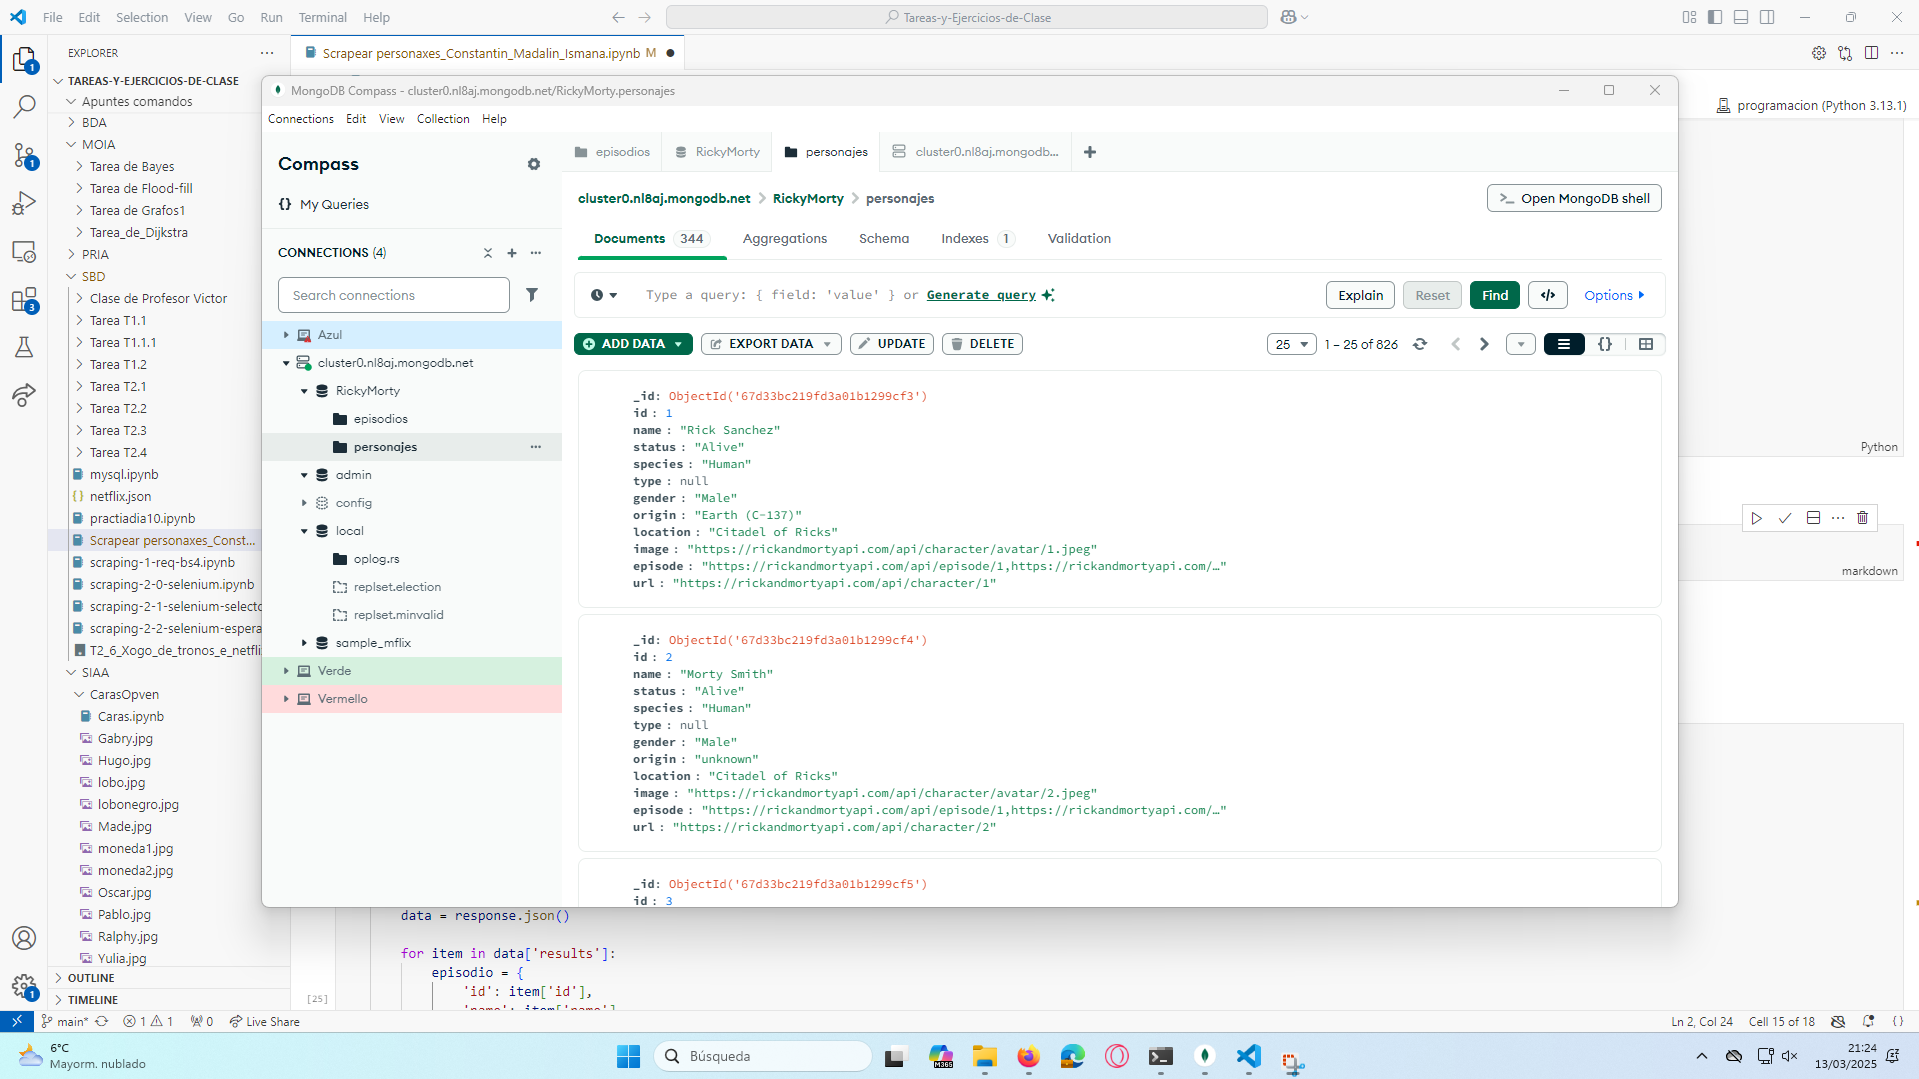

<h1>Coleccion de los datoso de los Episodios<h1>

In [25]:
coleccion_riki=db_ricki['episodios']

# Insertar todos los episodios desde la API
url_episodios = "https://rickandmortyapi.com/api/episode/"
page_num = requests.get(f"{url_episodios}?page=1").json()["info"]["pages"]

for page in range(1, page_num + 1):
    response = requests.get(f"{url_episodios}?page={page}")
    response.raise_for_status()
    data = response.json()
    
    for item in data['results']:
        episodio = {
            'id': item['id'],
            'name': item['name'],
            'air_date': item['air_date'],
            'episode': item['episode'],
            'characters': ','.join(item['characters']),
            'url': item['url']
        }
        coleccion_riki.insert_one(episodio)



print ("Antes de insertar, hai: ", coleccion_riki.count_documents({}), "documentos na colección episodios")

Antes de insertar, hai:  51 documentos na colección episodios


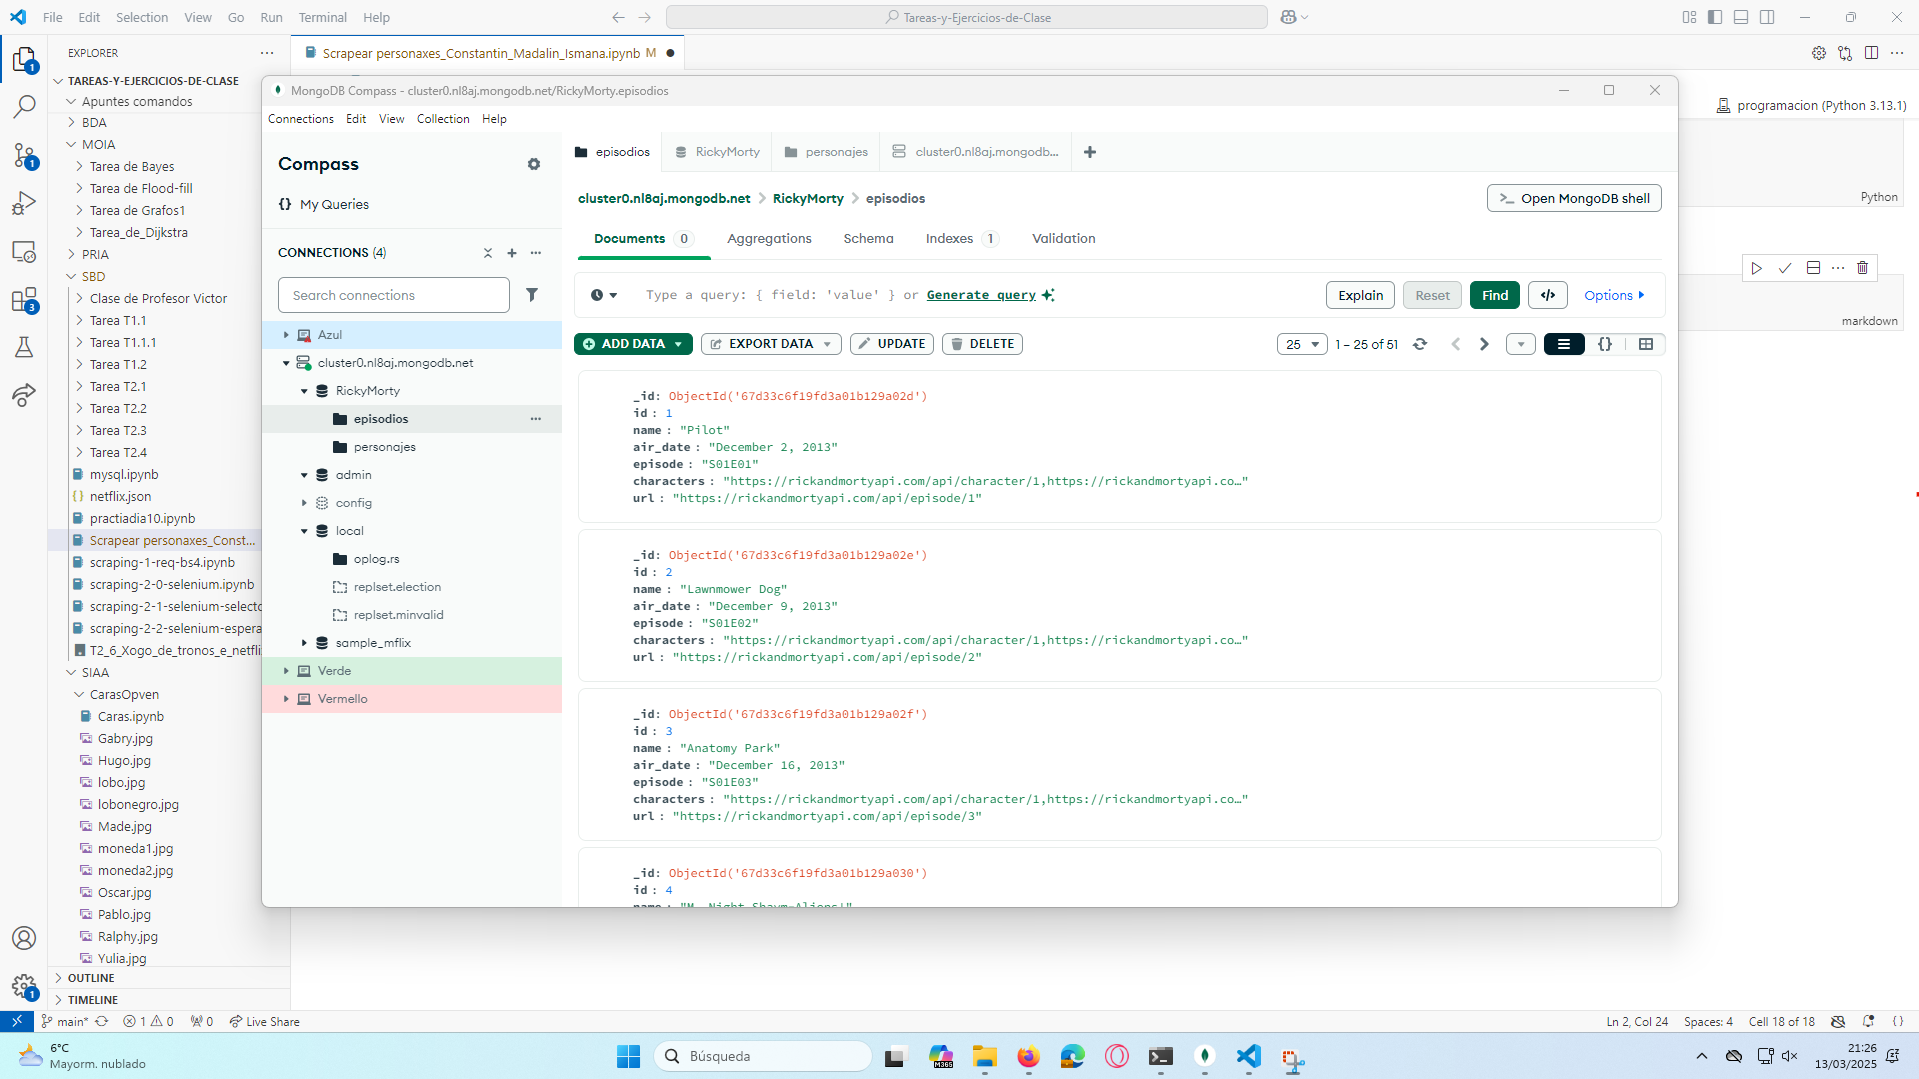

<h1>Redis<h1>

In [6]:
!conda install -y -c conda-forge redis-py sqlalchemy

Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: C:\Users\constantin.madalin.i\AppData\Local\miniconda3\envs\programacion

  added / updated specs:
    - redis-py
    - sqlalchemy


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    async-timeout-5.0.1        |     pyhd8ed1ab_1          11 KB  conda-forge
    redis-py-5.2.1             |     pyhd8ed1ab_1         175 KB  conda-forge
    sqlalchemy-2.0.39          |  py313ha7868ed_1         3.4 MB  conda-forge
    ------------------------------------------------------------
                                           Total:         3.6 MB

The following NEW packages will be INSTALLED:

  async-timeout      conda-forge/noarch::async-timeout-5.0.1-pyhd8ed1ab_1 
  redis-py           conda-forge/noarch::redis-py-5.2.1-pyhd8ed1ab_1 

T



==> WARNING: A newer version of conda exists. <==
    current version: 25.1.0
    latest version: 25.1.1

Please update conda by running

    $ conda update -n base -c defaults conda




In [3]:
empregamos_docker = True


r = redis.Redis(
    host='localhost',
    port=6379,
    password='123quetal123' 
)


In [43]:
# Configuración
url_personajes = "https://rickandmortyapi.com/api/character"
empregamos_docker = True

# Conectar a Redis
r = redis.Redis(
    host='localhost',  
    port=6379,
    password='123quetal123'
)

# Obtener datos de la API
response = requests.get(url_personajes)
data = response.json() if response.status_code == 200 else {}

# Guardar y recuperar datos en Redis
if empregamos_docker:
    r.json().set('personajes', '$', data)
    personajes = r.json().get('doc', '$.results')
    print(personajes)  # Muestra los personajes


[[{'id': 1, 'name': 'Rick Sanchez', 'status': 'Alive', 'species': 'Human', 'type': '', 'gender': 'Male', 'origin': {'name': 'Earth (C-137)', 'url': 'https://rickandmortyapi.com/api/location/1'}, 'location': {'name': 'Citadel of Ricks', 'url': 'https://rickandmortyapi.com/api/location/3'}, 'image': 'https://rickandmortyapi.com/api/character/avatar/1.jpeg', 'episode': ['https://rickandmortyapi.com/api/episode/1', 'https://rickandmortyapi.com/api/episode/2', 'https://rickandmortyapi.com/api/episode/3', 'https://rickandmortyapi.com/api/episode/4', 'https://rickandmortyapi.com/api/episode/5', 'https://rickandmortyapi.com/api/episode/6', 'https://rickandmortyapi.com/api/episode/7', 'https://rickandmortyapi.com/api/episode/8', 'https://rickandmortyapi.com/api/episode/9', 'https://rickandmortyapi.com/api/episode/10', 'https://rickandmortyapi.com/api/episode/11', 'https://rickandmortyapi.com/api/episode/12', 'https://rickandmortyapi.com/api/episode/13', 'https://rickandmortyapi.com/api/episode/

In [42]:
# Configuración
url_episodios = "https://rickandmortyapi.com/api/episode"
empregamos_docker = True

# Conectar a Redis
r = redis.Redis(
    host='localhost',  
    port=6379,
    password='123quetal123'
)

# Obtener datos de la API
response = requests.get(url_episodios)
data = response.json() if response.status_code == 200 else {}

# Guardar y recuperar datos en Redis
if empregamos_docker:
    r.json().set('episodios', '$', data)
    episodios = r.json().get('episodios', '$.results')
    print(episodios)  # Muestra los episodios

[[{'id': 1, 'name': 'Pilot', 'air_date': 'December 2, 2013', 'episode': 'S01E01', 'characters': ['https://rickandmortyapi.com/api/character/1', 'https://rickandmortyapi.com/api/character/2', 'https://rickandmortyapi.com/api/character/35', 'https://rickandmortyapi.com/api/character/38', 'https://rickandmortyapi.com/api/character/62', 'https://rickandmortyapi.com/api/character/92', 'https://rickandmortyapi.com/api/character/127', 'https://rickandmortyapi.com/api/character/144', 'https://rickandmortyapi.com/api/character/158', 'https://rickandmortyapi.com/api/character/175', 'https://rickandmortyapi.com/api/character/179', 'https://rickandmortyapi.com/api/character/181', 'https://rickandmortyapi.com/api/character/239', 'https://rickandmortyapi.com/api/character/249', 'https://rickandmortyapi.com/api/character/271', 'https://rickandmortyapi.com/api/character/338', 'https://rickandmortyapi.com/api/character/394', 'https://rickandmortyapi.com/api/character/395', 'https://rickandmortyapi.com/